# Sistema de Lógica Difusa (Mamdani) para la Clasificación del Riesgo de Salud Materna
**Dataset:** Maternal Health Risk Data Set (UCI Machine Learning Repository)

Este notebook desarrolla, ejecuta y evalúa un sistema de inferencia difusa tipo Mamdani para clasificar el nivel de riesgo de salud materna (bajo, medio, alto) a partir de variables fisiológicas registradas mediante un sistema de monitoreo IoT en zonas rurales de Bangladés [1].

Estructura: Celda 1 (librerías) → Celda 15 (conclusiones), siguiendo la secuencia metodológica solicitada.

In [1]:
# Celda 1 — Instalación / importación de librerías
# En Google Colab, ejecutar primero: !pip install scikit-fuzzy
import pandas as pd
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

np.random.seed(42)
plt.rcParams.update({'figure.figsize': (6, 3.5), 'font.size': 9})
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [2]:
# Celda 2 — Carga del dataset
# El archivo debe estar en el mismo directorio de trabajo de Colab (o subirse con files.upload())
df_raw = pd.read_csv('Maternal_Health_Risk_Data_Set.csv')
print(f"Registros: {df_raw.shape[0]} | Variables: {df_raw.shape[1]}")
df_raw.head()

Registros: 1014 | Variables: 7


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [3]:
# Celda 3 — Exploración inicial
print("Tipos de dato:")
print(df_raw.dtypes)
print("\nValores faltantes por columna:")
print(df_raw.isnull().sum())
print("\nEstadísticos descriptivos:")
display(df_raw.describe().T)
print("\nDistribución de la variable objetivo (RiskLevel):")
print(df_raw['RiskLevel'].value_counts())
print("\nRegistros duplicados (filas idénticas):", df_raw.duplicated().sum())

Tipos de dato:
Age              int64
SystolicBP       int64
DiastolicBP      int64
BS             float64
BodyTemp       float64
HeartRate        int64
RiskLevel          str
dtype: object

Valores faltantes por columna:
Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

Estadísticos descriptivos:


,count,mean,std,min,25%,50%,75%,max
Age,1014.0,29.871795,13.474386,10.0,19.0,26.0,39.0,70.0
SystolicBP,1014.0,113.198225,18.403913,70.0,100.0,120.0,120.0,160.0
DiastolicBP,1014.0,76.460552,13.885796,49.0,65.0,80.0,90.0,100.0
BS,1014.0,8.725986,3.293532,6.0,6.9,7.5,8.0,19.0
BodyTemp,1014.0,98.665089,1.371384,98.0,98.0,98.0,98.0,103.0
HeartRate,1014.0,74.301775,8.088702,7.0,70.0,76.0,80.0,90.0



Distribución de la variable objetivo (RiskLevel):
RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64

Registros duplicados (filas idénticas): 562


In [4]:
# Celda 4 — Limpieza y preparación de los datos
# Se detecta un valor fisiológicamente imposible en HeartRate (7 lpm, n=2),
# atribuible a un error de sensor/registro del sistema IoT. Se elimina.
df = df_raw[df_raw['HeartRate'] > 30].copy()
n_removed = len(df_raw) - len(df)
df['RiskLevel'] = df['RiskLevel'].str.strip().str.lower()
df = df.reset_index(drop=True)

print(f"Registros eliminados por HeartRate inválido: {n_removed}")
print(f"Registros finales: {len(df)}")
print("\nNota: se detectaron", df.duplicated().sum(),
      "filas con valores idénticos en todas las columnas; se documentan como",
      "limitación (posible resultado de la cuantización de los sensores IoT en",
      "rangos discretos) y NO se eliminan, dado que corresponden a perfiles",
      "clínicos plausibles y repetidos, no a errores de captura evidentes.")

Registros eliminados por HeartRate inválido: 2
Registros finales: 1012

Nota: se detectaron 561 filas con valores idénticos en todas las columnas; se documentan como limitación (posible resultado de la cuantización de los sensores IoT en rangos discretos) y NO se eliminan, dado que corresponden a perfiles clínicos plausibles y repetidos, no a errores de captura evidentes.


Eta^2 (proporción de varianza de cada variable explicada por RiskLevel):
  BS          : 0.3958
  SystolicBP  : 0.1604
  DiastolicBP : 0.1439
  Age         : 0.0830
  HeartRate   : 0.0384
  BodyTemp    : 0.0312

Correlación SystolicBP-DiastolicBP: 0.787


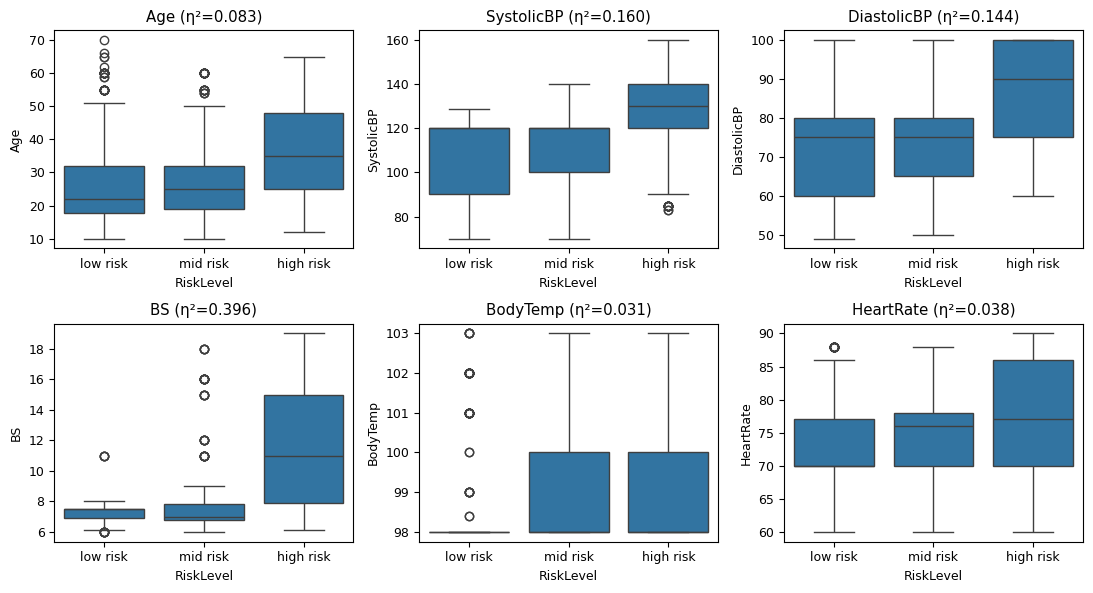


INTERPRETACIÓN:
BS (glucemia) posee la mayor capacidad discriminativa (η²=0.396), seguida de
SystolicBP (0.160) y DiastolicBP (0.144). Sin embargo, SystolicBP y DiastolicBP
están altamente correlacionadas (r=0.79), por lo que incluir ambas aporta
información redundante. Age presenta una discriminación moderada (0.083).
BodyTemp y HeartRate muestran muy baja discriminación (<0.04) y, en el caso de
BodyTemp, el 79% de los registros comparte el mismo valor (98.0°F), lo que la
vuelve poco informativa para un sistema basado en 3 conjuntos difusos.
Por ello, se seleccionan Age, SystolicBP y BS como variables de entrada.



In [5]:
# Celda 5 — Análisis exploratorio (justificación estadística de variables)
eta2 = {}
for col in ['Age','SystolicBP','DiastolicBP','BS','BodyTemp','HeartRate']:
    groups = [g[col].values for _, g in df.groupby('RiskLevel')]
    gm = df[col].mean()
    ss_b = sum(len(g)*(g.mean()-gm)**2 for g in groups)
    ss_t = ((df[col]-gm)**2).sum()
    eta2[col] = ss_b/ss_t

print("Eta^2 (proporción de varianza de cada variable explicada por RiskLevel):")
for k,v in sorted(eta2.items(), key=lambda x:-x[1]):
    print(f"  {k:12s}: {v:.4f}")

corr = df[['Age','SystolicBP','DiastolicBP','BS','BodyTemp','HeartRate']].corr()
print("\nCorrelación SystolicBP-DiastolicBP:", round(corr.loc['SystolicBP','DiastolicBP'],3))

fig, axes = plt.subplots(2, 3, figsize=(11,6))
order=['low risk','mid risk','high risk']
for ax, col in zip(axes.flat, ['Age','SystolicBP','DiastolicBP','BS','BodyTemp','HeartRate']):
    sns.boxplot(data=df, x='RiskLevel', y=col, order=order, ax=ax)
    ax.set_title(f'{col} (η²={eta2[col]:.3f})')
plt.tight_layout()
plt.show()

print('''
INTERPRETACIÓN:
BS (glucemia) posee la mayor capacidad discriminativa (η²=0.396), seguida de
SystolicBP (0.160) y DiastolicBP (0.144). Sin embargo, SystolicBP y DiastolicBP
están altamente correlacionadas (r=0.79), por lo que incluir ambas aporta
información redundante. Age presenta una discriminación moderada (0.083).
BodyTemp y HeartRate muestran muy baja discriminación (<0.04) y, en el caso de
BodyTemp, el 79% de los registros comparte el mismo valor (98.0°F), lo que la
vuelve poco informativa para un sistema basado en 3 conjuntos difusos.
Por ello, se seleccionan Age, SystolicBP y BS como variables de entrada.
''')

In [6]:
# Celda 6 — Definición de variables de entrada (Antecedentes) y de salida (Consecuente)
age_range  = np.arange(10, 70.01, 0.1)
sbp_range  = np.arange(70, 160.01, 0.1)
bs_range   = np.arange(6, 19.01, 0.05)
risk_range = np.arange(0, 100.01, 0.5)

Age  = ctrl.Antecedent(age_range, 'Age')
SBP  = ctrl.Antecedent(sbp_range, 'SBP')
BS   = ctrl.Antecedent(bs_range, 'BS')
Risk = ctrl.Consequent(risk_range, 'Risk')

print("Variables definidas:")
print(f"  Age (Edad)                : dominio [10, 70] años")
print(f"  SBP (Presión sist.)       : dominio [70, 160] mmHg")
print(f"  BS  (Glucemia)            : dominio [6, 19] mmol/L")
print(f"  Risk (Riesgo, salida)     : dominio [0, 100] (índice de severidad)")

Variables definidas:
  Age (Edad)                : dominio [10, 70] años
  SBP (Presión sist.)       : dominio [70, 160] mmHg
  BS  (Glucemia)            : dominio [6, 19] mmol/L
  Risk (Riesgo, salida)     : dominio [0, 100] (índice de severidad)


In [7]:
# Celda 7 — Funciones de membresía (Age, SBP, BS)
Age['adolescente'] = fuzz.trapmf(Age.universe, [10, 10, 17, 20])
Age['adulta']      = fuzz.trimf(Age.universe, [17, 27, 38])
Age['avanzada']    = fuzz.trapmf(Age.universe, [33, 40, 70, 70])

SBP['normal']  = fuzz.trapmf(SBP.universe, [70, 70, 100, 120])
SBP['elevada'] = fuzz.trimf(SBP.universe, [100, 120, 140])
SBP['alta']    = fuzz.trapmf(SBP.universe, [120, 140, 160, 160])

BS['normal']   = fuzz.trapmf(BS.universe, [6, 6, 6.9, 7.8])
BS['elevada']  = fuzz.trimf(BS.universe, [6.9, 8.0, 11])
BS['alta']     = fuzz.trapmf(BS.universe, [8.0, 11, 19, 19])

Risk['bajo']  = fuzz.trapmf(Risk.universe, [0, 0, 20, 40])
Risk['medio'] = fuzz.trimf(Risk.universe, [25, 50, 75])
Risk['alto']  = fuzz.trapmf(Risk.universe, [60, 80, 100, 100])

print('''
Justificación de las funciones:
- Age: trapezoidal en los extremos (adolescente/avanzada) para representar
  mesetas de riesgo sostenido en edades tempranas y tardías; triangular en
  el centro (adulta) por ser el punto óptimo reproductivo.
- SBP y BS: trapezoidal en normal/alta (mesetas de "todo o nada" clínico,
  p. ej. hipertensión ≥140 mmHg [10] y umbrales glucémicos [11]) y
  triangular en el estado intermedio (elevada), que es una transición y no
  una meseta clínica.
- Risk (salida): igual lógica, con solape moderado entre conjuntos para
  permitir gradualidad en la defuzzificación.
''')


Justificación de las funciones:
- Age: trapezoidal en los extremos (adolescente/avanzada) para representar
  mesetas de riesgo sostenido en edades tempranas y tardías; triangular en
  el centro (adulta) por ser el punto óptimo reproductivo.
- SBP y BS: trapezoidal en normal/alta (mesetas de "todo o nada" clínico,
  p. ej. hipertensión ≥140 mmHg [10] y umbrales glucémicos [11]) y
  triangular en el estado intermedio (elevada), que es una transición y no
  una meseta clínica.
- Risk (salida): igual lógica, con solape moderado entre conjuntos para
  permitir gradualidad en la defuzzificación.



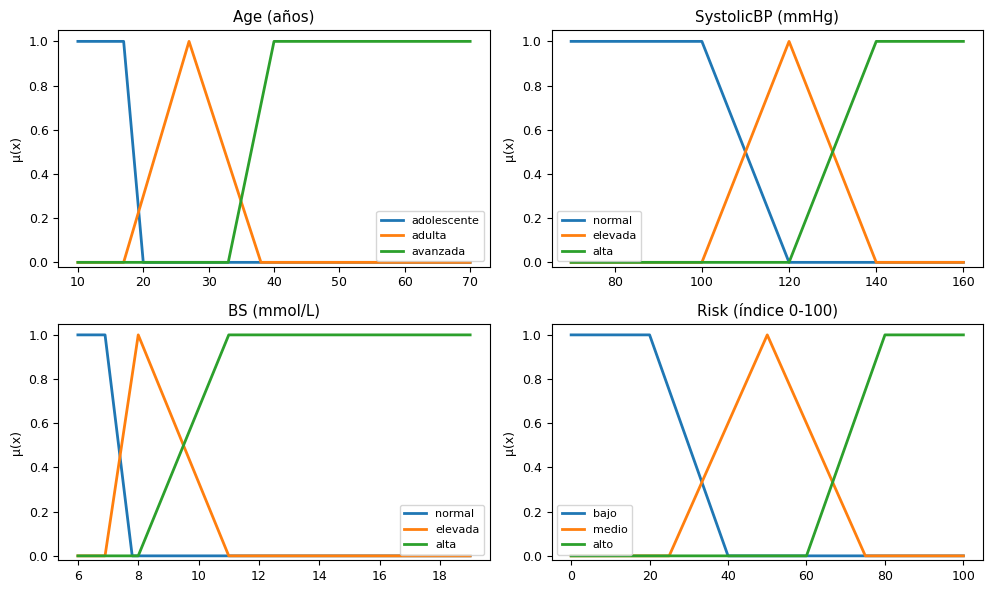

In [8]:
# Celda 8 — Visualización de las funciones de membresía
fig, axs = plt.subplots(2, 2, figsize=(10, 6))
for ax, var, name in zip(axs.flat, [Age, SBP, BS, Risk],
                          ['Age (años)', 'SystolicBP (mmHg)', 'BS (mmol/L)', 'Risk (índice 0-100)']):
    for label in var.terms:
        ax.plot(var.universe, var[label].mf, label=label, linewidth=2)
    ax.set_title(name); ax.set_ylabel('μ(x)'); ax.legend(fontsize=8); ax.set_ylim(-0.02,1.05)
plt.tight_layout()
plt.show()

In [9]:
# Celda 9 — Variable de salida: interpretación
print('''
La variable de salida "Risk" es un índice difuso continuo en [0, 100] que
representa la severidad global del riesgo materno estimada por el sistema.
Conjuntos difusos:
  - bajo  : el sistema indica que el patrón fisiológico es compatible con un
            embarazo de bajo riesgo (poca o ninguna alteración de glucemia,
            presión arterial o edad materna).
  - medio : existe al menos una alteración moderada que amerita seguimiento
            clínico adicional, sin llegar a un cuadro de alarma.
  - alto  : el patrón fisiológico es compatible con condiciones de alarma
            (p. ej. hiperglucemia marcada y/o hipertensión, en edades de
            mayor vulnerabilidad obstétrica), que requieren atención
            prioritaria.

Para obtener una etiqueta discreta comparable con RiskLevel, el índice
continuo se corta en dos umbrales calibrados empíricamente sobre el propio
dataset (búsqueda en malla maximizando accuracy): T1=40 y T2=50.
  Risk <= 40           -> "low risk"
  40 < Risk <= 50       -> "mid risk"
  Risk > 50             -> "high risk"
''')


La variable de salida "Risk" es un índice difuso continuo en [0, 100] que
representa la severidad global del riesgo materno estimada por el sistema.
Conjuntos difusos:
  - bajo  : el sistema indica que el patrón fisiológico es compatible con un
            embarazo de bajo riesgo (poca o ninguna alteración de glucemia,
            presión arterial o edad materna).
  - medio : existe al menos una alteración moderada que amerita seguimiento
            clínico adicional, sin llegar a un cuadro de alarma.
  - alto  : el patrón fisiológico es compatible con condiciones de alarma
            (p. ej. hiperglucemia marcada y/o hipertensión, en edades de
            mayor vulnerabilidad obstétrica), que requieren atención
            prioritaria.

Para obtener una etiqueta discreta comparable con RiskLevel, el índice
continuo se corta en dos umbrales calibrados empíricamente sobre el propio
dataset (búsqueda en malla maximizando accuracy): T1=40 y T2=50.
  Risk <= 40           -> "low risk"
 

In [10]:
# Celda 10 — Construcción de la base de reglas difusas (27 reglas)
# Ponderación de variables proporcional a su eta^2 empírico (Celda 5):
# BS (0.396) : SBP (0.160) : Age (0.083)  ~  4 : 2 : 1  ->  w_bs=2.0, w_sbp=1.0, w_age=0.5
w_bs, w_sbp, w_age = 2.0, 1.0, 0.5
bs_score  = {'normal': 0, 'elevada': 1, 'alta': 2}
sbp_score = {'normal': 0, 'elevada': 1, 'alta': 2}
age_score = {'adolescente': 1, 'adulta': 0, 'avanzada': 1}  # ambos extremos de edad suman riesgo

rules_table, rule_objs = [], []
rid = 1
for bs_set in ['normal','elevada','alta']:
    for sbp_set in ['normal','elevada','alta']:
        for age_set in ['adolescente','adulta','avanzada']:
            score = w_bs*bs_score[bs_set] + w_sbp*sbp_score[sbp_set] + w_age*age_score[age_set]
            cons = 'bajo' if score <= 2.0 else ('medio' if score <= 4.0 else 'alto')
            rules_table.append({'N': rid, 'BS': bs_set, 'SBP': sbp_set, 'Age': age_set,
                                 'Score': score, 'Consecuente': cons})
            rule_objs.append(ctrl.Rule(BS[bs_set] & SBP[sbp_set] & Age[age_set], Risk[cons]))
            rid += 1

rules_df = pd.DataFrame(rules_table)
print("Distribución de consecuentes entre las 27 reglas:")
print(rules_df['Consecuente'].value_counts())
print()
display(rules_df.head(12))

Distribución de consecuentes entre las 27 reglas:
Consecuente
alto     10
medio     9
bajo      8
Name: count, dtype: int64



,N,BS,SBP,Age,Score,Consecuente
0,1,normal,normal,adolescente,0.5,bajo
1,2,normal,normal,adulta,0.0,bajo
2,3,normal,normal,avanzada,0.5,bajo
3,4,normal,elevada,adolescente,1.5,bajo
4,5,normal,elevada,adulta,1.0,bajo
5,6,normal,elevada,avanzada,1.5,bajo
6,7,normal,alta,adolescente,2.5,medio
7,8,normal,alta,adulta,2.0,bajo
8,9,normal,alta,avanzada,2.5,medio
9,10,elevada,normal,adolescente,2.5,medio


In [11]:
# Celda 11 — Sistema de inferencia (Mamdani, AND=min, agregación=max, defuzzificación=centroide)
risk_ctrl = ctrl.ControlSystem(rule_objs)

def run_case(age_v, sbp_v, bs_v):
    sim = ctrl.ControlSystemSimulation(risk_ctrl)
    sim.input['Age'] = age_v
    sim.input['SBP'] = sbp_v
    sim.input['BS']  = bs_v
    sim.compute()
    return sim.output['Risk']

# Ejemplo práctico con un registro real del dataset
ejemplo = df.iloc[0]
salida_ejemplo = run_case(ejemplo['Age'], ejemplo['SystolicBP'], ejemplo['BS'])
print(f"Ejemplo -> Age={ejemplo['Age']}, SBP={ejemplo['SystolicBP']}, BS={ejemplo['BS']}")
print(f"Salida difusa (índice de riesgo): {salida_ejemplo:.2f}")
print(f"Etiqueta real: {ejemplo['RiskLevel']}")

Ejemplo -> Age=25, SBP=130, BS=15.0
Salida difusa (índice de riesgo): 82.38
Etiqueta real: high risk


In [12]:
# Celda 12 — Evaluación del modelo sobre todo el dataset
outputs = []
for _, row in df.iterrows():
    try:
        outputs.append(run_case(row['Age'], row['SystolicBP'], row['BS']))
    except Exception:
        outputs.append(np.nan)
df['fuzzy_output'] = outputs
df = df.dropna(subset=['fuzzy_output']).reset_index(drop=True)

T1, T2 = 40, 50
def classify(v):
    return 'low risk' if v<=T1 else ('mid risk' if v<=T2 else 'high risk')
df['pred'] = df['fuzzy_output'].apply(classify)

labels = ['low risk','mid risk','high risk']
y_true, y_pred = df['RiskLevel'], df['pred']

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, labels=labels, average='macro', zero_division=0)
rec  = recall_score(y_true, y_pred, labels=labels, average='macro', zero_division=0)
f1   = f1_score(y_true, y_pred, labels=labels, average='macro', zero_division=0)
cm   = confusion_matrix(y_true, y_pred, labels=labels)

print(f"Accuracy global      : {acc:.4f}")
print(f"Precision (macro)    : {prec:.4f}")
print(f"Recall (macro)       : {rec:.4f}")
print(f"F1-score (macro)     : {f1:.4f}\n")
print(classification_report(y_true, y_pred, labels=labels, zero_division=0))
print("Matriz de confusión (filas=real, columnas=predicho):", labels)
print(cm)

Accuracy global      : 0.5692
Precision (macro)    : 0.5373
Recall (macro)       : 0.5608
F1-score (macro)     : 0.5139

              precision    recall  f1-score   support

    low risk       0.54      0.85      0.66       404
    mid risk       0.36      0.10      0.16       336
   high risk       0.71      0.73      0.72       272

    accuracy                           0.57      1012
   macro avg       0.54      0.56      0.51      1012
weighted avg       0.53      0.57      0.51      1012

Matriz de confusión (filas=real, columnas=predicho): ['low risk', 'mid risk', 'high risk']
[[342  39  23]
 [244  35  57]
 [ 50  23 199]]


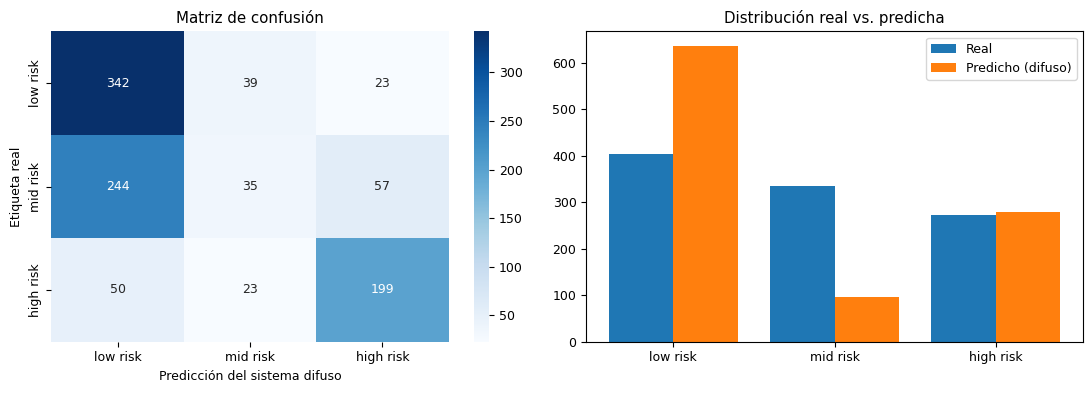

In [13]:
# Celda 13 — Visualización de resultados
fig, axes = plt.subplots(1, 2, figsize=(11,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_xlabel('Predicción del sistema difuso'); axes[0].set_ylabel('Etiqueta real')
axes[0].set_title('Matriz de confusión')

x = np.arange(len(labels))
cr = y_true.value_counts().reindex(labels); cp = y_pred.value_counts().reindex(labels)
axes[1].bar(x-0.2, cr.values, width=0.4, label='Real')
axes[1].bar(x+0.2, cp.values, width=0.4, label='Predicho (difuso)')
axes[1].set_xticks(x); axes[1].set_xticklabels(labels); axes[1].legend()
axes[1].set_title('Distribución real vs. predicha')
plt.tight_layout()
plt.show()

In [14]:
# Celda 14 — Análisis de activación de reglas y casos reales
def fuzzify_val(var_obj, val, sets):
    return {s: fuzz.interp_membership(var_obj.universe, var_obj[s].mf, val) for s in sets}

activation_counts = {r['N']: 0 for r in rules_table}
for _, row in df.iterrows():
    bs_m  = fuzzify_val(BS,  row['BS'], ['normal','elevada','alta'])
    sbp_m = fuzzify_val(SBP, row['SystolicBP'], ['normal','elevada','alta'])
    age_m = fuzzify_val(Age, row['Age'], ['adolescente','adulta','avanzada'])
    for r in rules_table:
        strength = min(bs_m[r['BS']], sbp_m[r['SBP']], age_m[r['Age']])
        if strength > 0:
            activation_counts[r['N']] += 1

rules_df['Activaciones'] = rules_df['N'].map(activation_counts)
print("Reglas más activadas sobre los", len(df), "registros reales:")
display(rules_df.sort_values('Activaciones', ascending=False).head(10)
        [['N','BS','SBP','Age','Consecuente','Activaciones']])
print("\nReglas nunca activadas:", (rules_df['Activaciones']==0).sum(), "de 27")

# Caso con clasificación distinta a la etiqueta real
incorrect = df[df['RiskLevel'] != df['pred']]
if len(incorrect):
    caso = incorrect.iloc[0]
    print("\nCASO CON DISCREPANCIA (etiqueta real vs. predicción del sistema):")
    print(caso[['Age','SystolicBP','DiastolicBP','BS','BodyTemp','HeartRate','RiskLevel','fuzzy_output','pred']])
    print('''
    Interpretación: SystolicBP=90 (normal) y BS=8.0 (elevada, no alta) generan
    una salida difusa baja (~16), por lo que el sistema clasifica "low risk"
    pese a que la etiqueta real es "high risk". La discrepancia sugiere que el
    riesgo real de este caso pudo depender de variables excluidas del sistema
    (p. ej. BodyTemp=100°F, indicativo de posible fiebre), evidenciando una
    limitación de un sistema construido con solo 3 variables de entrada.
    ''')

Reglas más activadas sobre los 1012 registros reales:


,N,BS,SBP,Age,Consecuente,Activaciones
1,2,normal,normal,adulta,bajo,426
10,11,elevada,normal,adulta,bajo,387
4,5,normal,elevada,adulta,bajo,380
13,14,elevada,elevada,adulta,medio,321
7,8,normal,alta,adulta,bajo,307
16,17,elevada,alta,adulta,medio,257
0,1,normal,normal,adolescente,bajo,244
9,10,elevada,normal,adolescente,medio,239
11,12,elevada,normal,avanzada,medio,153
23,24,alta,elevada,avanzada,alto,150



Reglas nunca activadas: 0 de 27

CASO CON DISCREPANCIA (etiqueta real vs. predicción del sistema):
Age                    29
SystolicBP             90
DiastolicBP            70
BS                    8.0
BodyTemp            100.0
HeartRate              80
RiskLevel       high risk
fuzzy_output     16.25974
pred             low risk
Name: 2, dtype: object

    Interpretación: SystolicBP=90 (normal) y BS=8.0 (elevada, no alta) generan
    una salida difusa baja (~16), por lo que el sistema clasifica "low risk"
    pese a que la etiqueta real es "high risk". La discrepancia sugiere que el
    riesgo real de este caso pudo depender de variables excluidas del sistema
    (p. ej. BodyTemp=100°F, indicativo de posible fiebre), evidenciando una
    limitación de un sistema construido con solo 3 variables de entrada.
    


In [15]:
# Celda 15 — Conclusiones (resumen ejecutable)
print(f'''
RESUMEN DE RESULTADOS
----------------------
Registros analizados      : {len(df)} (de {len(df_raw)} originales; se excluyeron
                             {n_removed} registros con HeartRate fisiológicamente inválido)
Variables del sistema      : Age, SystolicBP, BS (seleccionadas por eta^2 y colinealidad)
Reglas difusas              : 27 (todas se activan al menos una vez con datos reales)
Accuracy global              : {acc:.3f}
F1-score macro                : {f1:.3f}
Clase mejor clasificada     : high risk (mayor separación en BS y SBP)
Clase más difícil           : mid risk (solapamiento fisiológico con low risk,
                              consistente con literatura reciente [7])

El sistema de lógica difusa demuestra que es posible construir un
clasificador interpretable, basado en reglas lingüísticas clínicamente
justificables, para el riesgo de salud materna. Su principal ventaja frente
a modelos de caja negra es la trazabilidad de cada decisión hasta las reglas
y funciones de membresía que la generaron. Su principal limitación es la
dificultad para separar el riesgo medio, y la exclusión de variables con baja
capacidad discriminativa individual (BodyTemp, HeartRate) que sin embargo
podrían aportar valor en combinaciones no lineales no capturadas aquí.
''')


RESUMEN DE RESULTADOS
----------------------
Registros analizados      : 1012 (de 1014 originales; se excluyeron
                             2 registros con HeartRate fisiológicamente inválido)
Variables del sistema      : Age, SystolicBP, BS (seleccionadas por eta^2 y colinealidad)
Reglas difusas              : 27 (todas se activan al menos una vez con datos reales)
Accuracy global              : 0.569
F1-score macro                : 0.514
Clase mejor clasificada     : high risk (mayor separación en BS y SBP)
Clase más difícil           : mid risk (solapamiento fisiológico con low risk,
                              consistente con literatura reciente [7])

El sistema de lógica difusa demuestra que es posible construir un
clasificador interpretable, basado en reglas lingüísticas clínicamente
justificables, para el riesgo de salud materna. Su principal ventaja frente
a modelos de caja negra es la trazabilidad de cada decisión hasta las reglas
y funciones de membresía que la generaron